<a href="https://colab.research.google.com/github/Ekhwatenge/CSC-468-CODE-ALONG/blob/main/CSC_468.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
#@title 0. SETUP: IMPORT LIBRARIES
# ============================

# NumPy is a library that makes working with vectors and matrices easy.
import numpy as np

# Matplotlib is used to draw graphs (e.g., loss curves).
import matplotlib.pyplot as plt

# TensorFlow is a deep learning framework.
# Keras (inside TensorFlow) gives us a high-level API to build neural networks quickly.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# For reproducibility: if we set a fixed random seed,
# we will get the same random numbers every time we run the notebook.
np.random.seed(42)
tf.random.set_seed(42)

print("NumPy version:", np.__version__)
print("TensorFlow version:", tf.__version__)


NumPy version: 2.0.2
TensorFlow version: 2.19.0


In [5]:
#@title 1 Perceptron for AND / OR / NAND

# We want to teach the perceptron to learn functions like AND, OR, NAND.
# Each input is a pair (x1, x2), where each is 0 or 1.

# Create the input matrix X with all combinations of 0 and 1.
# Shape: (4 examples, 2 features)
X = np.array([
    [0, 0],  # example 1
    [0, 1],  # example 2
    [1, 0],  # example 3
    [1, 1]   # example 4
], dtype=np.float32)

# Create labels for each logic gate.
# We will reuse the same X, and just change y.

# AND gate truth table
# 0 AND 0 = 0
# 0 AND 1 = 0
# 1 AND 0 = 0
# 1 AND 1 = 1
y_and  = np.array([0, 0, 0, 1], dtype=np.float32)

# OR gate
y_or   = np.array([0, 1, 1, 1], dtype=np.float32)

# NAND gate (NOT AND)
y_nand = np.array([1, 1, 1, 0], dtype=np.float32)


def train_perceptron(X, y, lr=0.1, n_epochs=20):
    """
    Train a single-layer perceptron using the perceptron learning rule.

    Parameters:
        X: input data of shape (n_samples, n_features)
        y: labels (0 or 1) of shape (n_samples,)
        lr: learning rate (step size for weight updates)
        n_epochs: how many passes over the dataset

    Returns:
        w: learned weight vector of shape (n_features,)
        b: learned bias (scalar)
        predict: function that takes X_new and returns predicted labels (0 or 1)
    """
    n_samples, n_features = X.shape

    # Initialize weights and bias to zero.
    # w: one weight for each input feature (here 2 inputs -> 2 weights)
    w = np.zeros(n_features, dtype=np.float32)
    b = 0.0

    def predict_raw(X_in):
        """
        Compute the raw score: w^T x + b.
        This can be a single example or a batch of examples.
        """
        return np.dot(X_in, w) + b

    def predict(X_in):
        """
        Apply a step function to the raw score to get a binary prediction.
        If score >= 0 -> predict 1, else predict 0.
        """
        return (predict_raw(X_in) >= 0).astype(np.float32)

    # Training loop: repeat for n_epochs
    for epoch in range(n_epochs):
        # Loop through each training example
        for i in range(n_samples):
            xi = X[i]   # input vector (shape: (2,))
            yi = y[i]   # true label (0 or 1)

            # Current prediction for this example
            y_pred = predict(xi)

            # Error = (true label - predicted label)
            error = yi - y_pred

            # Perceptron update rule:
            # w_new = w_old + lr * error * x
            # b_new = b_old + lr * error
            w += lr * error * xi
            b += lr * error

        # (Optional) you can print weights each epoch to see learning progress.
        # print(f"Epoch {epoch}: w={w}, b={b}")

    # Return the learned parameters and the predict function
    return w, b, predict


# Train and evaluate perceptron on each gate
for name, targets in [("AND", y_and), ("OR", y_or), ("NAND", y_nand)]:
    print(f"\nTraining perceptron for {name} gate")
    w, b, predict = train_perceptron(X, targets)

    # Make predictions on the training set
    preds = predict(X)

    # Print the results for each input combination
    for xi, yi, pi in zip(X, targets, preds):
        print(f"X={xi}, true y={int(yi)}, predicted y={int(pi)}")

    print("Learned weights:", w, "bias:", b)
    print("-" * 40)



Training perceptron for AND gate
X=[0. 0.], true y=0, predicted y=0
X=[0. 1.], true y=0, predicted y=0
X=[1. 0.], true y=0, predicted y=0
X=[1. 1.], true y=1, predicted y=1
Learned weights: [0.2 0.1] bias: -0.20000002
----------------------------------------

Training perceptron for OR gate
X=[0. 0.], true y=0, predicted y=0
X=[0. 1.], true y=1, predicted y=1
X=[1. 0.], true y=1, predicted y=1
X=[1. 1.], true y=1, predicted y=1
Learned weights: [0.1 0.1] bias: -0.1
----------------------------------------

Training perceptron for NAND gate
X=[0. 0.], true y=1, predicted y=1
X=[0. 1.], true y=1, predicted y=1
X=[1. 0.], true y=1, predicted y=1
X=[1. 1.], true y=0, predicted y=0
Learned weights: [-0.2 -0.1] bias: 0.2
----------------------------------------


Epoch 0, loss=0.2558
Epoch 1000, loss=0.2498
Epoch 2000, loss=0.2494
Epoch 3000, loss=0.2484
Epoch 4000, loss=0.2454
Epoch 5000, loss=0.2342
Epoch 6000, loss=0.2046
Epoch 7000, loss=0.1720
Epoch 8000, loss=0.1532
Epoch 9000, loss=0.1438

XOR predictions after training:
Input X=[0. 0.], true y=0, predicted=0, prob=0.124
Input X=[0. 1.], true y=1, predicted=0, prob=0.481
Input X=[1. 0.], true y=1, predicted=1, prob=0.891
Input X=[1. 1.], true y=0, predicted=1, prob=0.508


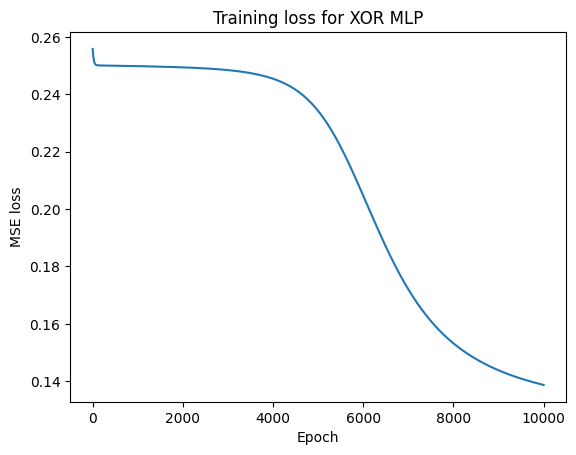

In [6]:
#@title 2. XOR with a 2-layer MLP (NumPy, backprop from scratch)


# XOR truth table:
# 0 XOR 0 = 0
# 0 XOR 1 = 1
# 1 XOR 0 = 1
# 1 XOR 1 = 0

# Reuse the same inputs as before
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

# Labels for XOR (we keep shape as (4,1) for matrix math)
y = np.array([[0], [1], [1], [0]], dtype=np.float32)

# -------------------------
# Activation functions
# -------------------------

def sigmoid(z):
    """
    Sigmoid activation function.
    Takes any real number and squashes it into the range (0, 1).
    """
    return 1.0 / (1.0 + np.exp(-z))


def sigmoid_derivative(a):
    """
    Derivative of sigmoid with respect to its input.
    Important: here 'a' is already sigmoid(z), not z.
    d/dz sigmoid(z) = sigmoid(z) * (1 - sigmoid(z))
    """
    return a * (1 - a)

# -------------------------
# Network architecture
# -------------------------

# Our network: 2 -> 2 -> 1
# - 2 input neurons (x1, x2)
# - 2 hidden neurons
# - 1 output neuron

n_inputs = 2
n_hidden = 2
n_outputs = 1

# Initialize weights with small random values (Gaussian distribution).
# W1: shape (2, 2) connecting input layer to hidden layer.
W1 = np.random.randn(n_inputs, n_hidden).astype(np.float32)
# b1: bias for hidden layer, shape (1, 2)
b1 = np.zeros((1, n_hidden), dtype=np.float32)

# W2: shape (2, 1) connecting hidden layer to output neuron.
W2 = np.random.randn(n_hidden, n_outputs).astype(np.float32)
# b2: bias for output neuron, shape (1, 1)
b2 = np.zeros((1, n_outputs), dtype=np.float32)

# -------------------------
# Training hyperparameters
# -------------------------

# Learning rate controls how big each gradient descent step is.
lr = 0.1

# Number of training epochs (full passes through the training data).
n_epochs = 10000

# To track the loss over time for plotting.
loss_history = []

# -------------------------
# Training loop
# -------------------------

for epoch in range(n_epochs):
    # ========== FORWARD PASS ==========
    # Step 1: compute hidden layer linear combination: z1 = X W1 + b1
    # Shape: (4,2) @ (2,2) + (1,2) -> (4,2)
    z1 = X @ W1 + b1

    # Step 2: apply sigmoid activation at hidden layer to get a1
    a1 = sigmoid(z1)

    # Step 3: compute output layer linear combination: z2 = a1 W2 + b2
    # Shape: (4,2) @ (2,1) + (1,1) -> (4,1)
    z2 = a1 @ W2 + b2

    # Step 4: apply sigmoid activation at output layer to get final prediction a2
    a2 = sigmoid(z2)

    # ========== LOSS COMPUTATION ==========
    # We use Mean Squared Error (MSE) for simplicity:
    # MSE = average over examples of (y_true - y_pred)^2
    loss = np.mean((y - a2)**2)
    loss_history.append(loss)

    # ========== BACKWARD PASS (BACKPROP) ==========
    # Goal: compute gradients of the loss w.r.t. all weights and biases.

    # dL/da2: derivative of loss wrt output activations
    # For MSE: d/d(a2) ( (y - a2)^2 ) = 2*(a2 - y)
    # We divide by number of examples to get the average.
    dL_da2 = 2 * (a2 - y) / y.shape[0]

    # dL/dz2: chain rule: dL/dz2 = dL/da2 * da2/dz2
    # We already know da2/dz2 = sigmoid_derivative(a2)
    dL_dz2 = dL_da2 * sigmoid_derivative(a2)

    # Gradients for W2 and b2
    # z2 = a1 @ W2 + b2
    # dL/dW2 = a1^T @ dL/dz2
    dL_dW2 = a1.T @ dL_dz2
    # dL/db2 = sum over examples of dL/dz2
    dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True)

    # For the hidden layer:
    # First propagate the gradient back from z2 to a1:
    # dL/da1 = dL/dz2 @ W2^T
    dL_da1 = dL_dz2 @ W2.T

    # Then from a1 to z1 using derivative of sigmoid
    dL_dz1 = dL_da1 * sigmoid_derivative(a1)

    # Gradients for W1 and b1
    # z1 = X @ W1 + b1
    # dL/dW1 = X^T @ dL/dz1
    dL_dW1 = X.T @ dL_dz1
    # dL/db1 = sum over examples of dL/dz1
    dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True)

    # ========== PARAMETER UPDATE ==========
    # Gradient descent step: subtract gradient scaled by learning rate
    W2 -= lr * dL_dW2
    b2 -= lr * dL_db2
    W1 -= lr * dL_dW1
    b1 -= lr * dL_db1

    # (Optional) print loss occasionally to see training progress
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, loss={loss:.4f}")

# -------------------------
# After training: test the network
# -------------------------

def predict(X_in):
    """
    Compute the network's predictions for input X_in.
    Returns:
      - binary predictions (0 or 1)
      - raw probabilities from the sigmoid output
    """
    z1 = X_in @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)
    # threshold at 0.5 to convert probabilities into 0/1 labels
    return (a2 > 0.5).astype(int), a2

# Get predictions on the XOR dataset
y_hat, y_prob = predict(X)

print("\nXOR predictions after training:")
for xi, yi, pi, prob in zip(X, y, y_hat, y_prob):
    print(f"Input X={xi}, true y={int(yi[0])}, predicted={int(pi[0])}, prob={prob[0]:.3f}")

# Plot how the loss decreased over time
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE loss")
plt.title("Training loss for XOR MLP")
plt.show()



In [7]:
#@title 3. MNIST classification with a simple MLP (Keras)


# Goal: use a neural network to classify hand-written digits (0-9)
# from the MNIST dataset.

# -------------------------
# Load MNIST dataset
# -------------------------

# Keras provides MNIST for us.
# x_train, x_test: images
# y_train, y_test: labels (digits 0-9)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Original x_train shape:", x_train.shape)
print("Original x_test shape:", x_test.shape)

# Each image is 28x28 pixels (grayscale).
# Values are in [0, 255]. We will scale to [0, 1] for better training.

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Keras layers usually expect a "channel" dimension.
# For grayscale images, channels = 1.
# So we expand the last dimension from (28,28) -> (28,28,1)
x_train = np.expand_dims(x_train, -1)
x_test  = np.expand_dims(x_test, -1)

print("x_train shape after adding channel:", x_train.shape)
print("Number of train samples:", x_train.shape[0])
print("Number of test samples:", x_test.shape[0])

# Number of classes (digits 0 to 9)
num_classes = 10
input_shape = (28, 28, 1)

# -------------------------
# One-hot encode labels
# -------------------------

# Convert y (like 3) to a one-hot vector (0,0,0,1,0,...,0)
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_test_cat  = keras.utils.to_categorical(y_test, num_classes)

print("y_train_cat shape:", y_train_cat.shape)

# -------------------------
# Build the MLP model
# -------------------------

# We will use a simple neural network:
# Input (28x28x1) -> Flatten -> Dense(128, relu) -> Dense(10, softmax)
model = keras.Sequential(
    [
        # Input layer, telling Keras the shape of our images
        keras.Input(shape=input_shape),

        # Flatten converts each 28x28 image into a 1D vector of length 784.
        layers.Flatten(),

        # Dense layer with 128 neurons and ReLU activation.
        # This is a fully connected layer that learns useful features.
        layers.Dense(128, activation="relu"),

        # Output layer: 10 neurons (one for each digit), with softmax activation.
        # Softmax converts raw scores into probabilities that sum to 1.
        layers.Dense(num_classes, activation="softmax"),
    ]
)

# Show a summary of the model: layers, output shapes, and number of parameters.
model.summary()

# -------------------------
# Compile the model
# -------------------------

# We need to specify:
# - loss function: how wrong the model is (for classification we use categorical_crossentropy)
# - optimizer: how we update weights (Adam is a popular choice)
# - metrics: what to track (we'll track accuracy)
model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"],
)

# -------------------------
# Train the model
# -------------------------

# We train for a few epochs (passes through the training data).
# validation_split=0.1 means 10% of the training data is used for validation.
history = model.fit(
    x_train,
    y_train_cat,
    batch_size=128,    # process 128 images at a time
    epochs=5,          # number of passes over the whole train set
    validation_split=0.1,
)

# -------------------------
# Evaluate on the test set
# -------------------------

test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original x_train shape: (60000, 28, 28)
Original x_test shape: (10000, 28, 28)
x_train shape after adding channel: (60000, 28, 28, 1)
Number of train samples: 60000
Number of test samples: 10000
y_train_cat shape: (60000, 10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8974 - loss: 0.3678 - val_accuracy: 0.9555 - val_loss: 0.1689
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9497 - loss: 0.1738 - val_accuracy: 0.9663 - val_loss: 0.1250
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9641 - loss: 0.1248 - val_accuracy: 0.9695 - val_loss: 0.1062
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9728 - loss: 0.0960 - val_accuracy: 0.9712 - val_loss: 0.0962
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9783 - loss: 0.0767 - val_accuracy: 0.9717 - val_loss: 0.0902
Test accuracy: 0.9692


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


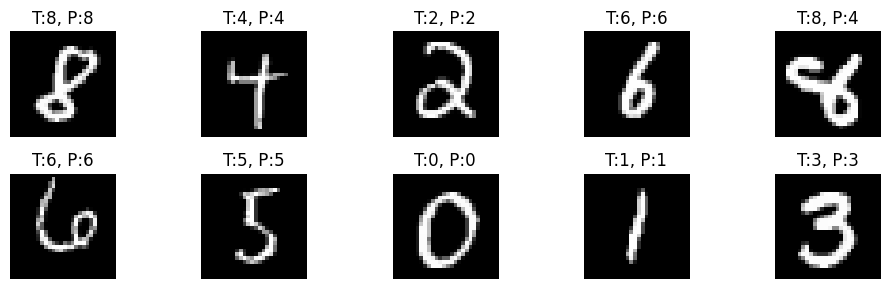

In [8]:
#@title Visualize predictions on test digits

idx = np.random.choice(len(x_test), size=10, replace=False)
x_sample = x_test[idx]
y_true = y_test[idx]

y_pred_probs = model.predict(x_sample)
y_pred = np.argmax(y_pred_probs, axis=1)

plt.figure(figsize=(10,3))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_sample[i].squeeze(), cmap="gray")
    plt.axis("off")
    plt.title(f"T:{y_true[i]}, P:{y_pred[i]}")
plt.tight_layout()
plt.show()


In [9]:
#@title 4. (Optional demo) Simple CNN for MNIST (just model definition)

# This model replaces the Flatten+Dense at the start with convolutional layers.
# CNNs are much better suited for images than plain MLPs.

cnn_model = keras.Sequential(
    [
        keras.Input(shape=input_shape),

        # First convolutional layer: 32 filters, size 3x3
        # "same" padding means output has same height/width as input.
        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        # Max pooling layer: downsample the image by taking max over 2x2 blocks
        layers.MaxPooling2D((2, 2)),

        # Second convolutional layer: 64 filters
        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        # Flatten to go from feature maps to a vector
        layers.Flatten(),

        # Dense layer to combine extracted features
        layers.Dense(64, activation="relu"),

        # Output layer: 10 classes, softmax for probabilities
        layers.Dense(num_classes, activation="softmax"),
    ]
)

cnn_model.summary()



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)